In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import numpy as np
from shapely.ops import split
from pyfonts import load_google_font

# Map

In [2]:
# Load shape file
gdf = gpd.read_file("shapefiles/cb_2018_us_state_5m.shp")

In [3]:
# Check projection
gdf.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [4]:
# Reproject to EPSG:9311
gdf_9311 = gdf.to_crs("EPSG:9311")

In [5]:
# List of states to remove
states_to_remove = ["Hawaii", "United States Virgin Islands", "Guam", "Commonwealth of the Northern Mariana Islands",
                    "American Samoa", "Puerto Rico", "Alaska"]
# Filter out states to remove
gdf_9311 = gdf_9311[~gdf_9311["NAME"].isin(states_to_remove)]

## Split Oklahoma

In [6]:
# Select Oklahoma
oklahoma = gdf_9311.loc[gdf_9311["NAME"] == "Oklahoma"].iloc[0]

#Extract geometry
poly = oklahoma.geometry

# Bounding box coordinates
minx, miny, maxx, maxy = poly.bounds

# Splitting line
split_line = LineString([
    ((minx + maxx)/1.1, miny - 10000),  
    ((minx + maxx)/1.1, maxy + 10000)
])

# Split the polygon into 2
split_result = split(poly, split_line)

# Remove Oklahoma
gdf_9311 = gdf_9311[gdf_9311["NAME"] != "Oklahoma"]

# New gdf with split geometries
split_gdf = gpd.GeoDataFrame(
    [oklahoma, oklahoma],  
    geometry=list(split_result.geoms),
    crs=gdf_9311.crs
).reset_index(drop=True)

# Rename the two new polygons
split_gdf["STUSPS"] = ["OK1", "OK2"]

# Concatenate original gdf_933 with new gdf
gdf_9311 = gpd.pd.concat([gdf_9311, split_gdf], ignore_index=True)

# Select relevant columns
gdf_9311 = gdf_9311[["NAME", "STUSPS", "geometry"]]

In [7]:
gdf_9311.shape

(50, 3)

# Present location

In [8]:
# Load data
present = pd.read_csv("present.csv")

In [9]:
# Remove trailing whitespace 
present["Present Location"] = present["Present Location"].astype(str)
present = present.apply(lambda x: x.str.strip())
present["Present Location"] = pd.to_numeric(present["Present Location"])

In [10]:
# Filter out Alaska, Oklahoma, Texas
present = present[~present["State"].isin(["AK", "OK", "TX"])]
# Filter out Minnesota with wrong value
present = present[~((present["State"] == "MN") & (present["Present Location"] == 38))]
# Add missing Arkansas, splitted Oklahoma and Texas
new_rows = pd.DataFrame([["AR", 12018], ["OK1", 68], ["OK2", np.nan], ["TX", 12142]], columns=present.columns)
present = pd.concat([present, new_rows], ignore_index=True)

In [11]:
present.shape

(50, 2)

In [12]:
# Merge gdf_9311 with present df
gdf_present = pd.merge(gdf_9311, present, left_on="STUSPS", right_on="State")

In [13]:
gdf_present.shape

(50, 5)

In [14]:
# Function to color states
def present_color(name):
    if name in ["WA", "TX", "IA", "KY", "NH", "NJ"]:
        return "#d6c9b5" # lightgrey
    elif name in ["OR", "CO", "AR", "PA", "RI"]:
        return "#bd2043" # crimson
    elif name in ["CA", "WY", "OK1", "IL", "FL", "ME", "CT", "MD"]:
        return "#ddb032" # gold
    elif name in ["ID", "AZ", "WI", "SC", "NY", "MO"]:
        return "#323c74" # blue
    elif name in ["NV", "MN", "NE", "LA", "IN", "NC", "VT", "OK2"]:
        return "#ce6e6e" # pink
    elif name in ["MT", "KS", "AL", "VA"]:
        return "#44513c" # green
    elif name in ["UT", "SD", "MI", "TN", "WV"]:
        return "#6d5136" # brown
    elif name in ["ND", "NM", "OH", "MA", "MS"]:
        return "#b79e84" # tan
    else:
        return "#1c1a15" # black
        
# Apply function
gdf_present["color"] = gdf_present["State"].apply(present_color)

# Georgia reference point

In [15]:
# Select Georgia 
georgia = gdf_9311[gdf_9311["NAME"] == "Georgia"]

# Compute centroid
GA_centroid = georgia.geometry.centroid.iloc[0]  

# Projected coords
GAX = GA_centroid.x
GAY = GA_centroid.y

# Params for present quiver

In [16]:
# Subset for quiver
present_subset = gdf_present.dropna()
present_subset = present_subset.copy()

# Compute centroids
present_subset["centroid"] = present_subset.geometry.centroid
Xp = present_subset.centroid.x.values
Yp = present_subset.centroid.y.values

# Compute vectors from Georgia
Up = Xp - GAX
Vp = Yp - GAY

# Normalize length
arrow_length = 150000
lengths = np.sqrt(Up**2 + Vp**2)

# Avoid division by zero
lengths = np.where(lengths == 0, 1, lengths)

Ups = Up / lengths * arrow_length
Vps = Vp / lengths * arrow_length

# Birthplace

In [17]:
# Load data
birthplace = pd.read_csv("birthplace.csv")

In [18]:
# Remove trailing whitespace 
birthplace["Birthplace"] = birthplace["Birthplace"].astype(str)
birthplace = birthplace.apply(lambda x: x.str.strip())
birthplace["Birthplace"] = pd.to_numeric(birthplace["Birthplace"])

In [19]:
# Filter out Alaska and Oklahoma
birthplace = birthplace[~birthplace["State"].isin(["AK", "OK"])]
# Add missing Arkansas and splitted Oklahoma
new_bprows = pd.DataFrame([["AR", 37], ["OK1", 1], ["OK2", 8]], columns=birthplace.columns)
birthplace = pd.concat([birthplace, new_bprows], ignore_index=True)

In [20]:
birthplace.shape

(37, 2)

In [21]:
# Merge gdf_9311 with Birthplace df
gdf_birthplace = pd.merge(gdf_9311, birthplace, left_on="STUSPS", right_on="State", how="left")

In [22]:
# Function to color states
def birthplace_color(name):
    if name in ["OR", "CO", "ND", "AR", "MI", "FL", "VT", "ME"]:
        return "#d6c9b5" # lightgrey
    elif name in ["MT", "IL", "SC", "MA", "OK1"]:
        return "#bd2043" # crimson
    elif name in ["ID", "TX", "MN", "KY", "NY"]:
        return "#ddb032" # gold
    elif name in ["UT", "SD", "MS", "PA", "NH", "WI"]:
        return "#323c74" # blue
    elif name in ["CA", "NM", "MO", "AL", "OH", "VA"]:
        return "#dea399" # pink
    elif name in ["NV", "KS", "IA", "TN", "MD", "CT"]:
        return "#44513c" # green
    elif name in ["WA", "WY", "OK2", "IL", "NC", "IN"]:
        return "#6d5136" # brown
    elif name in ["AZ", "NE", "LA", "WV", "NJ"]:
        return "#b79e84" # tan
    else:
        return "#1c1a15" # black
        
gdf_birthplace["color"] = gdf_birthplace["STUSPS"].apply(birthplace_color)

# Params for birthplace quiver

In [23]:
# Subset for quiver
birthplace_subset = gdf_birthplace.dropna()
birthplace_subset = birthplace_subset.copy()

# Compute centroids
birthplace_subset["centroid"] = birthplace_subset.geometry.centroid
Xbp = birthplace_subset.centroid.x.values
Ybp = birthplace_subset.centroid.y.values

# Compute vectors to Georgia
Ubp = GAX - Xbp
Vbp = GAY - Ybp

# Normalize length
arrow_length = 150000
lengths = np.sqrt(Ubp**2 + Vbp**2)

# Avoid division by zero
lengths = np.where(lengths == 0, 1, lengths)

Ubps = Ubp / lengths * arrow_length
Vbps = Vbp / lengths * arrow_length

# Plot

In [24]:
# Custom font
font_bold = load_google_font("Public Sans", weight="bold")
font_light = load_google_font("Public Sans", weight="thin")

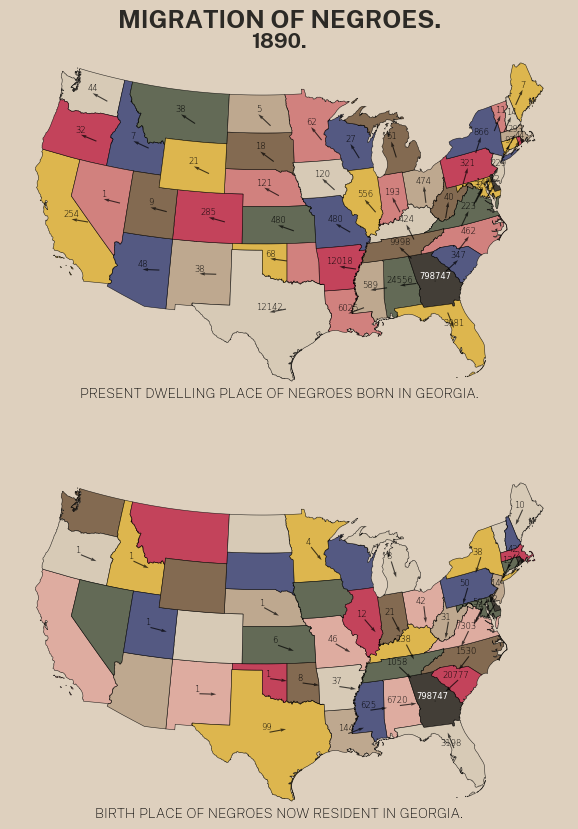

In [25]:
# Create figure
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 10), facecolor="#ded0be")  

## Present location
# Plot polygons
gdf_present.plot(
    ax=ax[0],
    color=gdf_present["color"],
    alpha=0.8,
    ec="black",
    lw=0.4
)

# Iterate over rows to annotate polygons
for i, row in present_subset.iterrows():    
    centroid = row.geometry.centroid
    text_color = "white" if row["NAME"] in ["Georgia"] else "black"
    text_weight = "normal" if row["NAME"] in ["Georgia"] else "light"    
    ax[0].text(centroid.x, centroid.y+50000, f"{row["Present Location"]:.0f}",
               color=text_color, weight=text_weight, ha="center", va="center", fontsize=6)

# Quiver plot
ax[0].quiver(Xp, Yp, Ups, Vps, angles="xy", scale_units="xy", scale=1, color="black", alpha=0.7, pivot="tip", width=0.002)

## Birthplace
# Plot polygons
gdf_birthplace.plot(
    ax=ax[1],
    color=gdf_birthplace["color"],
    alpha=0.8,
    ec="black",
    lw=0.4
)

# Iterate over rows to annotate polygons
for i, row in birthplace_subset.iterrows():    
    centroid = row.geometry.centroid
    text_color = "white" if row["NAME"] in ["Georgia"] else "black"
    text_weight = "normal" if row["NAME"] in ["Georgia"] else "light"    
    ax[1].text(centroid.x-25000, centroid.y+50000, f"{row["Birthplace"]:.0f}",
               color=text_color, weight=text_weight, ha="center", va="center", fontsize=6)
    
# Quiver plot
ax[1].quiver(Xbp, Ybp, Ubps, Vbps, angles="xy", scale_units="xy", scale=1, color="black", alpha=0.7, pivot="tail", width=0.002)

# Remove axis
ax[0].axis("off")
ax[1].axis("off")

## Titles 
fig.text(0.5, 0.9, "MIGRATION OF NEGROES.", size=18, alpha=0.8,  font=font_bold, ha="center")
fig.text(0.5, 0.88, "1890.", font=font_bold, size=15, alpha=0.8, ha="center")
fig.text(0.5, 0.53, "PRESENT DWELLING PLACE OF NEGROES BORN IN GEORGIA.", font=font_light, ha="center")
fig.text(0.5, 0.11, "BIRTH PLACE OF NEGROES NOW RESIDENT IN GEORGIA.", font=font_light,ha="center")

plt.show()

#plt.savefig("plate08.jpg")

In [26]:
import matplotlib.image as mpimg
from PIL import Image

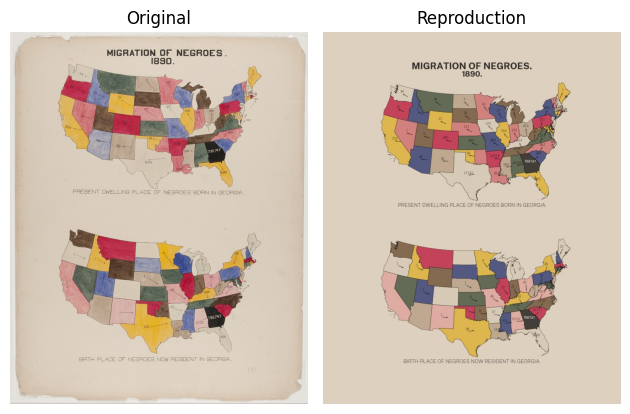

In [27]:
# Load images 
image1 = Image.open("original-plate-08.jpg")
image2 = Image.open("plate08.jpg")

# Convert to numpy arrays
images = [np.array(image1), np.array(image2)]
titles = ["Original", "Reproduction"]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2)

# Loop through axes, images, and titles
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title)

# Adjust the layout and show
plt.tight_layout()
plt.show()

# Save the combined figure 
#plt.savefig("plate08sidebyside.png", dpi=300)